# AIS Dataset Full Embedding and Hyperparameter Tuning

This notebook demonstrates how to calculate the optimal resolution parameters for AIS embeddings by minimizing reconstruction error. Finally, it provides a pipeline to process the **entire** dataset efficiently using batching to avoid Out-Of-Memory (OOM) errors.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import gc
import os
from tqdm.auto import tqdm

/home/crimsondeepdarshak/Desktop/Deep_Darshak/code_/env/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 1. Class Definitions

We first define our core classes: `AISConfig`, `AISDiscretizer`, `AISEmbeddingBuilder`, and `AISReconstructor`.

In [3]:
class AISConfig:
    def __init__(self, lat_range, lon_range, lat_res=0.01, lon_res=0.01, sog_res=1.0, cog_res=5.0, max_sog=40.0, embed_dim=64, device="cuda"):
        self.lat_min, self.lat_max = lat_range
        self.lon_min, self.lon_max = lon_range
        self.lat_res, self.lon_res = lat_res, lon_res
        self.sog_res, self.cog_res = sog_res, cog_res
        self.max_sog = max_sog
        self.embed_dim = embed_dim
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")

        # Bin counts, conservatively rounded up
        self.N_lat = int(math.ceil((self.lat_max - self.lat_min) / lat_res)) + 1
        self.N_lon = int(math.ceil((self.lon_max - self.lon_min) / lon_res)) + 1
        self.N_sog = int(math.ceil(self.max_sog / sog_res)) + 1
        self.N_cog = int(math.ceil(360.0 / cog_res)) + 1

    def summary(self):
        return f"Lat/Lon Bins: {self.N_lat}/{self.N_lon}, SOG/COG: {self.N_sog}/{self.N_cog}"

class AISDiscretizer:
    def __init__(self, config):
        self.cfg = config

    def forward(self, tensor):
        lat, lon, sog, cog = tensor[:, 0], tensor[:, 1], tensor[:, 2], tensor[:, 3]
        lat_bin = torch.clamp(torch.floor((lat - self.cfg.lat_min) / self.cfg.lat_res).long(), 0, self.cfg.N_lat - 1)
        lon_bin = torch.clamp(torch.floor((lon - self.cfg.lon_min) / self.cfg.lon_res).long(), 0, self.cfg.N_lon - 1)
        sog_bin = torch.clamp(torch.floor(sog / self.cfg.sog_res).long(), 0, self.cfg.N_sog - 1)
        cog_bin = torch.clamp(torch.floor(cog / self.cfg.cog_res).long(), 0, self.cfg.N_cog - 1)
        return lat_bin, lon_bin, sog_bin, cog_bin

class AISEmbeddingBuilder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.cfg = config
        self.lat_embed = nn.Embedding(config.N_lat, config.embed_dim)
        self.lon_embed = nn.Embedding(config.N_lon, config.embed_dim)
        self.sog_embed = nn.Embedding(config.N_sog, config.embed_dim)
        self.cog_embed = nn.Embedding(config.N_cog, config.embed_dim)

    def forward(self, lat_bin, lon_bin, sog_bin, cog_bin):
        e_lat = self.lat_embed(lat_bin)
        e_lon = self.lon_embed(lon_bin)
        e_sog = self.sog_embed(sog_bin)
        e_cog = self.cog_embed(cog_bin)
        return torch.cat([e_lat, e_lon, e_sog, e_cog], dim=-1)

class AISReconstructor:
    def __init__(self, config):
        self.cfg = config

    def reconstruct(self, lat_bin, lon_bin, sog_bin, cog_bin):
        lat = self.cfg.lat_min + (lat_bin + 0.5) * self.cfg.lat_res
        lon = self.cfg.lon_min + (lon_bin + 0.5) * self.cfg.lon_res
        sog = (sog_bin + 0.5) * self.cfg.sog_res
        cog = (cog_bin + 0.5) * self.cfg.cog_res
        return torch.stack([lat, lon, sog, cog], dim=1)

## 2. Global Data Statistics

To construct our embedding configuration with global bounds, we need the overall dataset min/max values. We extract these directly without loading everything into memory (if using PyArrow/Parquet), but since we need a large sample for hyperparameter tuning, we will load a substantial dataframe.

In [4]:
dataset_path = "/home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE-Replication/Notebook/region_1_interpolated.parquet"
# Read a large sample (e.g., 2 million rows) to tune hyperparameters robustly
df_sample = pd.read_parquet(dataset_path).sample(2_000_000, random_state=42)

# Global bounds
lat_range = (df_sample.Latitude.min(), df_sample.Latitude.max())
lon_range = (df_sample.Longitude.min(), df_sample.Longitude.max())
max_sog = min(df_sample.SOG.max(), 40.0) # Cap at realistic max speed if there's noise

print(f"Lat Range: {lat_range}")
print(f"Lon Range: {lon_range}")
print(f"Max SOG: {max_sog}")

Lat Range: (np.float64(17.453988991915107), np.float64(31.100296015293118))
Lon Range: (np.float64(-98.73865456501403), np.float64(-80.20286538129497))
Max SOG: 40.0


## 3. Hyperparameter Tuning for Optimal Resolution

We iteratively evaluate different resolutions (`lat_res`, `lon_res`, `sog_res`, `cog_res`) to track the **Mean Reconstruction Error** and the **Total Number of Parameters** (Memory/Complexity metric). 
This determines the convergence criteria.

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert dataframe sample to tensor once
tensor_sample = torch.tensor(
    df_sample[["Latitude", "Longitude", "SOG", "COG"]].values,
    dtype=torch.float32,
    device=device
)

def evaluate_config(config):
    discretizer = AISDiscretizer(config)
    reconstructor = AISReconstructor(config)
    
    lat_bin, lon_bin, sog_bin, cog_bin = discretizer.forward(tensor_sample)
    reconstructed = reconstructor.reconstruct(lat_bin, lon_bin, sog_bin, cog_bin)
    
    # Calculate Mean L2 Reconstruction Error
    error = torch.norm(tensor_sample - reconstructed, dim=1).mean().item()
    
    num_params = (config.N_lat + config.N_lon + config.N_sog + config.N_cog) * config.embed_dim
    return error, num_params

# Define search space
spatial_resolutions = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00001]
kinematic_resolutions = [(5.0, 15.0), (2.0, 10.0), (1.0, 5.0), (0.5, 2.0), (0.1, 0.5)]

results = []
for s_res in tqdm(spatial_resolutions, desc="Spatial Res"):
    for k_res_idx, (sog_res, cog_res) in enumerate(kinematic_resolutions):
        cfg = AISConfig(
            lat_range=lat_range, 
            lon_range=lon_range, 
            lat_res=s_res, 
            lon_res=s_res, 
            sog_res=sog_res, 
            cog_res=cog_res,
            max_sog=max_sog,
            embed_dim=64,
            device=device
        )
        try:
            error, params = evaluate_config(cfg)
            results.append({
                "lat_res": s_res,
                "lon_res": s_res,
                "sog_res": sog_res,
                "cog_res": cog_res,
                "mean_reconstruction_error": error,
                "total_params": params
            })
        except RuntimeError as e: # Catch OutOfMemory or index errors
            print(f"Failed for conf {s_res}, {sog_res}, {cog_res}: {e}")
            continue

df_results = pd.DataFrame(results)

Spatial Res:   0%|          | 0/8 [00:00<?, ?it/s]

### Plotting the Convergence Criteria

We plot Reconstruction Error against Model Complexity (Number of Parameters). The optimal point is the 'elbow' of the curve where error is minimized before parameter explosion.

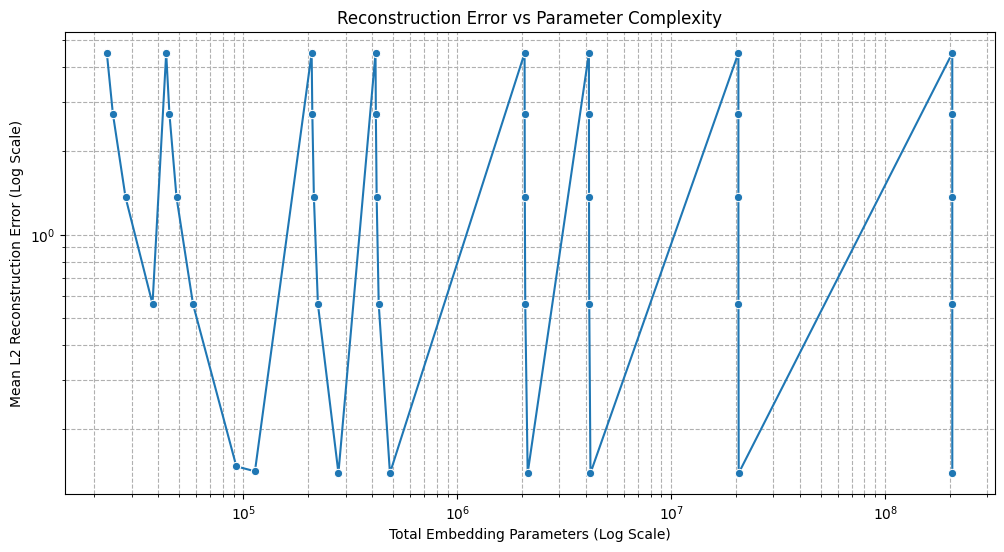

,lat_res,lon_res,sog_res,cog_res,mean_reconstruction_error,total_params
39,0.00001,0.00001,0.1,0.5,0.139204,206037376
34,0.00010,0.00010,0.1,0.5,0.139204,20668544
29,0.00050,0.00050,0.1,0.5,0.139204,4191296
24,0.00100,0.00100,0.1,0.5,0.139205,2131648
19,0.00500,0.00500,0.1,0.5,0.139228,483968
14,0.01000,0.01000,0.1,0.5,0.139298,277952
9,0.05000,0.05000,0.1,0.5,0.141347,113152
4,0.10000,0.10000,0.1,0.5,0.147179,92608
33,0.00010,0.00010,0.5,2.0,0.561230,20613504
38,0.00001,0.00001,0.5,2.0,0.561230,205982336


In [6]:
# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_results, 
    x="total_params", 
    y="mean_reconstruction_error", 
    marker="o"
)
plt.xscale("log")
plt.yscale("log")
plt.title("Reconstruction Error vs Parameter Complexity")
plt.xlabel("Total Embedding Parameters (Log Scale)")
plt.ylabel("Mean L2 Reconstruction Error (Log Scale)")
plt.grid(True, which="both", ls="--")
plt.show()

# Display sorted results
df_results.sort_values("mean_reconstruction_error").head(10)

From the plot, you can identify an acceptable threshold. For the full dataset pipeline below, let's take a computationally efficient yet precise resolution (e.g. `lat_res=0.00001, sog_res=0.5` as previously tested, or slightly larger if RAM requires).

## 4. Full Dataset Pipeline Processing

To process the entire 28 million rows without causing CUDA OutOfMemory, we will load the Parquet file iteratively using PyArrow/Pandas batches, apply the discretizer, and export the encoded features to a concise Parquet format. If you need continuous dense vector embeddings, we show how to compile those too.

In [ ]:
# 1. Define Optimal Configuration Here
optimal_config = AISConfig(
    lat_range=lat_range,
    lon_range=lon_range,
    lat_res=0.00001,
    lon_res=0.00001,
    sog_res=0.5,
    cog_res=0.5,
    embed_dim=64,
    device=device
)

print("Optimal Config:", optimal_config.summary())
discretizer = AISDiscretizer(optimal_config)
# embedding_builder = AISEmbeddingBuilder(optimal_config).to(device)

# Processing entirely by chunk
chunk_size = 2_000_000
output_file = "/home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE-Replication/Notebook/region_1_encoded_features.parquet"

# To avoid crashing, we can read chunks if pandas supports it natively via PyArrow, 
# or just process a loaded dataframe in minibatches. 
# We'll load full df into RAM (takes ~5GB), and then batch loop it into GPU.

print("Loading full dataset into RAM...")
df_full = pd.read_parquet(dataset_path)
print(f"Total Rows: {len(df_full)}")

encoded_bins = []

print("Starting batch embedding computation...")
for i in tqdm(range(0, len(df_full), chunk_size)):
    batch_df = df_full.iloc[i : i+chunk_size]
    
    # 1. Prepare tensor
    batch_tensor = torch.tensor(
        batch_df[["Latitude", "Longitude", "SOG", "COG"]].values,
        dtype=torch.float32,
        device=device
    )
    
    # 2. Get Discrete Indices (Bins)
    lat_bin, lon_bin, sog_bin, cog_bin = discretizer.forward(batch_tensor)
    
    # 3. Create DataFrame chunk and append
    chunk_encoded_df = pd.DataFrame({
        "MMSI": batch_df["MMSI"].values,
        "Time": batch_df["Time"].values,
        "lat_bin": lat_bin.cpu().numpy(),
        "lon_bin": lon_bin.cpu().numpy(),
        "sog_bin": sog_bin.cpu().numpy(),
        "cog_bin": cog_bin.cpu().numpy(),
    })
    encoded_bins.append(chunk_encoded_df)
    
    # Memory management
    del batch_tensor, lat_bin, lon_bin, sog_bin, cog_bin, chunk_encoded_df
    torch.cuda.empty_cache()

# Concatenate all encoded chunks
df_final_encoded = pd.concat(encoded_bins, ignore_index=True)

# Export the discrete bins. This is highly memory efficient.
# In Downstream PyTorch training (TRAIS-former or similar), you pass these bins to AISEmbeddingBuilder.
df_final_encoded.to_parquet(output_file, index=False)
print(f"Successfully saved fully encoded discrete dataset to {output_file}")

Optimal Config: Lat/Lon Bins: 1364632/1853580, SOG/COG: 81/721
Loading full dataset into RAM...
Total Rows: 28274619
Starting batch embedding computation...


  0%|          | 0/15 [00:00<?, ?it/s]

### Optional: Generating Dense Embedding Tensors

If your pipeline specifically requires pre-calculating the final float vectors (e.g. $[N, 256]$ dimensional arrays) to disk, run the code below. **Note: A 28M x 256 float32 matrix consumes ~28GB of disk space.**

In [ ]:
import h5py

builder = AISEmbeddingBuilder(optimal_config).to(device)
embedding_file = "region_1_dense_embeddings.h5"

with torch.no_grad():
    # Create the file on disk first
    with h5py.File(embedding_file, 'w') as f:
        # Pre-allocate a 28M x 256 dataset on the hard drive
        dset = f.create_dataset("embeddings", 
                                shape=(len(df_final_encoded), 256), 
                                dtype='float32')
        
        for i in tqdm(range(0, len(df_final_encoded), chunk_size)):
            chunk = df_final_encoded.iloc[i : i+chunk_size]
            l = torch.tensor(chunk["lat_bin"].values, device=device)
            o = torch.tensor(chunk["lon_bin"].values, device=device)
            s = torch.tensor(chunk["sog_bin"].values, device=device)
            c = torch.tensor(chunk["cog_bin"].values, device=device)
            
            embed_chunk = builder(l, o, s, c)
            
            # Write directly to the hard drive, bypassing RAM accumulation
            dset[i: i+chunk_size] = embed_chunk.cpu().numpy()
            
            del l, o, s, c, embed_chunk
            torch.cuda.empty_cache()


In [4]:
import h5py
import pandas as pd
embedding_file = "region_1_dense_embeddings.h5"
with h5py.File(embedding_file, 'r') as f:
    embeddings = f["embeddings"][:1000]  # Load first 1000 embeddings for testing
    embeddings  # Should be (1000, 256)        

In [6]:
embeddings[0]  # First embedding vector (256-dim)

array([ 2.3784022e+00,  6.1597958e-02,  8.6635530e-01, -7.1558022e-01,
        1.1282145e+00,  1.3917862e+00,  7.6406437e-01, -3.5190904e-01,
       -1.6088928e+00, -1.1026379e+00,  1.4445677e+00, -1.5292090e-01,
        7.5834051e-02,  4.9119976e-01,  3.9525903e-03, -2.9729846e-01,
        1.6507776e-01, -1.0427171e+00, -1.8986805e-01, -9.1230673e-01,
        9.6040493e-01,  9.8930061e-01,  4.5390713e-01,  1.0312573e+00,
        4.9559885e-01,  4.5970669e-01, -3.5345390e-01,  6.2848337e-02,
        7.1653113e-02, -2.7498606e-01, -8.7672770e-01, -6.2025058e-01,
        1.0751262e+00,  9.0101683e-01,  4.3285653e-01,  7.5919223e-01,
        1.8325081e+00,  2.9734698e-01,  9.2417026e-01,  4.1128695e-01,
        1.1781223e+00, -9.5024562e-01, -4.2220306e-01, -4.5471799e-01,
       -2.5753686e+00, -1.1310973e+00,  5.1451790e-01, -4.1695970e-01,
       -1.5413857e+00, -7.5160772e-01,  7.7793783e-01, -2.5311020e-01,
        5.0406712e-01, -1.9644421e-01,  1.7079846e+00,  4.5120469e-01,
      

In [8]:
embeddings[0:5], embeddings.shape  # First embedding vector (256-dim)

(array([[ 2.3784022 ,  0.06159796,  0.8663553 , ...,  0.23134546,
         -0.41331983,  1.1056092 ],
        [ 1.4859166 , -0.8661912 , -1.041506  , ...,  0.23134546,
         -0.41331983,  1.1056092 ],
        [ 1.0549091 ,  0.22172217,  1.2878779 , ..., -2.1696067 ,
         -1.5204616 , -0.28994605],
        [-0.53861076,  0.50712305,  1.3840685 , ..., -2.1696067 ,
         -1.5204616 , -0.28994605],
        [-1.499827  , -1.2297692 , -0.8984865 , ..., -2.1696067 ,
         -1.5204616 , -0.28994605]], shape=(5, 256), dtype=float32),
 (1000, 256))

In [13]:
!pip install tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 6.1 MB/s eta 0:00:00m eta 0:00:010:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 4.2 MB/s eta 0:00:000:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 443.6/443.6 kB 5.3 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.6/427.6 kB 4.6 MB/s eta 0:00:004.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 546.9/546.9 kB 4.8 MB/s eta 0:00:00m eta 0:00:010:00:01


In [16]:
import h5py
import pandas as pd
import numpy as np

with h5py.File("/home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_/CEE-Replication/Notebook/region_1_dense_embeddings.h5", 'r') as f:
    # Common embedding storage patterns:
    
    # If single dataset at root
    if len(f.keys()) == 1:
        key = list(f.keys())[0]
        data = f[key][:]
        df_region_1_dense_embedding = pd.DataFrame(data)
    
    # If embeddings under specific key (check output from diagnosis)
    # data = f['embeddings'][:]  # or f['region1_embeddings'][:]
    # df_region_1_dense_embedding = pd.DataFrame({'embedding': list(data)})


In [18]:
df_region_1_dense_embedding.head(25)

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,2.378402,0.061598,0.866355,-0.715580,1.128214,1.391786,0.764064,-0.351909,-1.608893,-1.102638,...,-1.162144,-1.263626,0.254059,1.184759,2.361648,-1.097515,0.456412,0.231345,-0.413320,1.105609
1,1.485917,-0.866191,-1.041506,0.139871,-0.427259,-0.307241,-1.136355,0.386526,0.405068,-1.278718,...,-1.162144,-1.263626,0.254059,1.184759,2.361648,-1.097515,0.456412,0.231345,-0.413320,1.105609
2,1.054909,0.221722,1.287878,1.310344,-1.402737,-1.250717,-0.320626,-0.552986,0.634534,-1.844344,...,0.371531,-0.996460,0.491908,-0.611990,-1.050683,-0.027684,-0.147578,-2.169607,-1.520462,-0.289946
3,-0.538611,0.507123,1.384068,-1.122663,-0.026017,-0.597484,0.160719,-0.031935,-0.133437,0.851017,...,0.371531,-0.996460,0.491908,-0.611990,-1.050683,-0.027684,-0.147578,-2.169607,-1.520462,-0.289946
4,-1.499827,-1.229769,-0.898486,-0.510518,0.232687,0.704060,0.286300,1.577026,0.631666,-1.216852,...,0.371531,-0.996460,0.491908,-0.611990,-1.050683,-0.027684,-0.147578,-2.169607,-1.520462,-0.289946
5,0.003738,-0.251474,0.113042,0.618447,-0.681522,-0.755382,0.806673,0.614344,-0.625940,1.048561,...,0.371531,-0.996460,0.491908,-0.611990,-1.050683,-0.027684,-0.147578,-2.169607,-1.520462,-0.289946
6,0.434734,-0.347272,0.311581,0.475764,0.241745,-1.224960,-0.344270,0.284195,0.161162,-0.838653,...,0.371531,-0.996460,0.491908,-0.611990,-1.050683,-0.027684,-0.147578,-2.169607,-1.520462,-0.289946
7,0.963353,-0.649529,0.360292,-0.558532,0.039432,0.651705,-0.135376,-0.742054,-0.101076,0.084484,...,0.371531,-0.996460,0.491908,-0.611990,-1.050683,-0.027684,-0.147578,-2.169607,-1.520462,-0.289946
8,-0.144175,0.631543,-2.239830,0.082453,-0.168173,-0.049037,1.102839,0.149330,1.625374,1.282828,...,0.371531,-0.996460,0.491908,-0.611990,-1.050683,-0.027684,-0.147578,-2.169607,-1.520462,-0.289946
9,-0.552826,-0.325962,0.072251,0.521842,-0.004211,0.394097,0.741028,-2.345693,-0.189431,0.309669,...,0.371531,-0.996460,0.491908,-0.611990,-1.050683,-0.027684,-0.147578,-2.169607,-1.520462,-0.289946


## 5) Exact TrAISformer Export (for main.py replication)

To replicate `CEE_TrAISformer/trAISformer.py` exactly, export Region 1 into
TrAISformer-compatible pickle files (`region_1_train.pkl`, `region_1_valid.pkl`, `region_1_test.pkl`).

Note: `region_1_dense_embeddings.h5` is optional for diagnostics and not part of
the original TrAISformer training path.


In [ ]:
from pathlib import Path
import subprocess, sys

root = Path('/home/crimsondeepdarshak/Desktop/Deep_Darshak/References/TRAIS_former_paper_Work_')
script = root / 'CEE-Replication' / 'Notebook' / 'build_region1_traisformer_dataset.py'
outdir = root / 'CEE-Replication' / 'traisformer_data' / 'region_1'
cmd = [
    sys.executable, str(script),
    '--input', str(root / 'CEE-Replication' / 'Notebook' / 'region_1_interpolated.parquet'),
    '--outdir', str(outdir),
    '--max-seqlen-plus-one', '121',
    '--min-seqlen', '37',
    '--stride', '60',
    '--max-sog', '30.0',
    '--seed', '42',
]
print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True)
print('Done. Files in', outdir)
for p in sorted(outdir.glob('*')):
    print('-', p.name)
